# FastText: Fast Text Classification Baseline

**Objective**: Fast text classification on OCR-extracted text from images (EN, MS, ZH)

**Data Source**: Uses noisy OCR labels from `ocr_images_noisy/{EN,MY,CN}/` if available, otherwise falls back to `ocr_images/`.

**Why FastText**:
- Extremely fast training & inference
- Subword embeddings (handles out-of-vocabulary words well)
- Baseline for text-only modality
- No GPU required

**Key Features**:
- Automatic fallback from noisy to original images
- 60/40 split strategy matching audio dataset methodology
- Detailed per-language accuracy metrics
- Classification report with precision/recall/F1 scores
- Confusion matrix visualization

In [1]:
# Setup and Dependencies
# Verify all required packages are installed; install missing ones automatically.
import subprocess
import sys

packages = ['fasttext', 'pandas', 'numpy', 'matplotlib', 'scikit-learn']
print('Checking dependencies...')
for pkg in packages:
    try:
        __import__(pkg)
        print(f'[OK] {pkg}')
    except ImportError:
        print(f'[Installing] {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

Checking dependencies...
[OK] fasttext
[OK] pandas
[OK] numpy
[OK] matplotlib
[Installing] scikit-learn...


In [2]:
# Imports
# Load all necessary libraries for text processing, model training, and evaluation.
import fasttext
import os
import csv
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json
import re

# Text cleaning utility: normalize text by removing newlines, tabs, and extra spaces.
# This ensures consistent input format for FastText model.
def clean_text(s: str) -> str:
    """Clean text by removing special characters and collapsing whitespace."""
    if not isinstance(s, str):
        s = str(s)
    # Replace newlines, tabs with spaces
    s = re.sub(r"[\r\n\t]+", " ", s)
    # Collapse multiple spaces into one
    s = re.sub(r"\s+", " ", s)
    return s.strip()

# Wrapper for FastText prediction with error handling.
# Handles edge cases like numpy 2.x compatibility and empty predictions.
def safe_predict(model, text, k=1):
    """
    Safely predict language label with fallback error handling.
    Cleans text, then calls model.predict(); returns labels and probabilities.
    Falls back to 'unknown' if prediction fails.
    """
    cleaned = clean_text(text)
    try:
        labels, probs = model.predict(cleaned, k=k)
        return labels, probs
    except ValueError as e:
        # Fallback: return unknown label with zero probability
        return ["__label__unknown"], np.array([0.0] * k)

print('[OK] All imports successful')

[OK] All imports successful


In [3]:
# Configuration
# Point to noisy OCR images directory. If ocr_images_noisy does not exist, will fall back to ocr_images.
OCR_NOISY_DIR = os.path.join(os.getcwd(), 'ocr_images_noisy')
OCR_BASE_DIR = OCR_NOISY_DIR if os.path.exists(OCR_NOISY_DIR) else os.path.join(os.getcwd(), 'ocr_images')

LANGS = ['EN', 'MY', 'CN']
LANG_MAP = {'EN': 0, 'MY': 1, 'CN': 2} 
LANG_NAMES = ['English', 'Malay', 'Mandarin']

# FastText training hyperparameters (will be updated by tuning cell below).
EPOCH = 25
LR = 0.5
DIM = 100   # embedding dimension
MINN = 3    # min character n-gram
MAXN = 6    # max character n-gram
WORD_NGRAMS = 1  # word n-grams (1 = unigrams)

print(f'OCR base dir: {OCR_BASE_DIR}')
print(f'Using: {"NOISY images" if OCR_BASE_DIR == OCR_NOISY_DIR else "ORIGINAL images"}')
print(f'Languages: {LANGS}')
print(f'FastText config (initial): epoch={EPOCH}, lr={LR}, dim={DIM}, minn={MINN}, maxn={MAXN}, wordNgrams={WORD_NGRAMS}')

OCR base dir: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images_noisy
Using: NOISY images
Languages: ['EN', 'MY', 'CN']
FastText config (initial): epoch=25, lr=0.5, dim=100, minn=3, maxn=6, wordNgrams=1


In [4]:
# Load OCR dataset from labels.csv or labels_noisy.csv files.
# Tries noisy labels first (if available), otherwise falls back to original labels.
texts = []
labels = []

for lang in LANGS:
    lang_dir = os.path.join(OCR_BASE_DIR, lang)
    
    # Try noisy labels first, then fall back to original labels
    labels_file = os.path.join(lang_dir, 'labels_noisy.csv')
    if not os.path.exists(labels_file):
        labels_file = os.path.join(lang_dir, 'labels.csv')
    
    if not os.path.exists(labels_file):
        print(f"[Warning] {lang}: labels.csv not found at {labels_file}")
        continue
    
    count = 0
    with open(labels_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if 'text' in row and row['text'].strip():
                texts.append(clean_text(row['text']))
                labels.append(LANG_MAP[lang])
                count += 1
    
    print(f"[OK] {lang}: {count} text samples loaded")

print(f"\n[Summary] Total samples: {len(texts)}")
if len(texts) == 0:
    print("[Error] No OCR data found! Generate OCR images first.")

[OK] EN: 5000 text samples loaded
[OK] MY: 5000 text samples loaded
[OK] CN: 5000 text samples loaded

[Summary] Total samples: 15000


In [6]:
# Data Splitting Strategy: single stratified 70/15/15 split across the FULL dataset.
# This uses 100% of the `labels.csv` samples and produces train/val/test = 70%/15%/15%.

# Convert lists to numpy arrays for sklearn splitting
texts_array = np.array(texts)
labels_array = np.array(labels)

# Step 1: Split into train (70%) and temp (30%)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts_array, labels_array, test_size=0.30, random_state=42, stratify=labels_array
)

# Step 2: Split temp into val and test (each 15% of total => half of temp)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"[OK] Full-data split (70/15/15):\  ")
print(f"  Total: {len(texts_array)} samples\    ")
print(f"  Train: {len(train_texts)} samples ({100*len(train_texts)/len(texts_array):.1f}% of total)\    ")
print(f"  Val:   {len(val_texts)} samples ({100*len(val_texts)/len(texts_array):.1f}% of total)\    ")
print(f"  Test:  {len(test_texts)} samples ({100*len(test_texts)/len(texts_array):.1f}% of total)\  ")

# Verify stratification: Check that each language is represented fairly across splits.
print(f"\n[Summary] Label distribution (full dataset):\ ")
for lang_id, lang_name in enumerate(LANG_NAMES):
    train_count = np.sum(train_labels == lang_id)
    val_count = np.sum(val_labels == lang_id)
    test_count = np.sum(test_labels == lang_id)
    print(f"  {lang_name}: Train {train_count} | Val {val_count} | Test {test_count}\   ")

[OK] Full-data split (70/15/15):\  
  Total: 15000 samples\    
  Train: 10500 samples (70.0% of total)\    
  Val:   2250 samples (15.0% of total)\    
  Test:  2250 samples (15.0% of total)\  

[Summary] Label distribution (full dataset):\ 
  English: Train 3500 | Val 750 | Test 750\   
  Malay: Train 3500 | Val 750 | Test 750\   
  Mandarin: Train 3500 | Val 750 | Test 750\   


In [7]:
# Prepare FastText training file in the required format: __label__LANGUAGE text_content.
# FastText requires one training example per line with this exact format.
import tempfile

train_file = os.path.join(os.getcwd(), 'fasttext_train.txt')

# Write training data to file in FastText format.
with open(train_file, 'w', encoding='utf-8') as f:
    for text, label in zip(train_texts, train_labels):
        lang_label = LANG_NAMES[label].lower()
        cleaned = clean_text(text)
        # FastText format: __label__LANGUAGE text_content (one per line)
        f.write(f"__label__{lang_label} {cleaned}\n")

print(f"[OK] FastText training file created: {train_file}")
print(f"  Total training lines: {len(train_texts)}")

[OK] FastText training file created: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\fasttext_train.txt
  Total training lines: 10500


In [8]:
# Hyperparameter sweep for FastText (grid over lr, epoch, wordNgrams, dim)
from itertools import product

search_space = {
    'lr': [0.1, 0.3, 0.5],
    'epoch': [10, 20, 30],
    'wordNgrams': [1, 2],
    'dim': [50, 100],
}

print('[Tuning] Starting FastText grid search over hyperparameters...')
print(search_space)

best = None
results = []

for lr, epoch, wordNgrams, dim in product(search_space['lr'], search_space['epoch'], search_space['wordNgrams'], search_space['dim']):
    model_tmp = fasttext.train_supervised(
        train_file,
        epoch=epoch,
        lr=lr,
        dim=dim,
        minn=MINN,
        maxn=MAXN,
        wordNgrams=wordNgrams,
        loss='softmax',
        thread=4,
    )

    # Evaluate on validation set
    val_preds = []
    for text in val_texts:
        pred_labels, _ = safe_predict(model_tmp, text, k=1)
        pred = pred_labels[0].replace('__label__', '')
        pred_id = LANG_NAMES.index(pred.capitalize()) if pred.capitalize() in LANG_NAMES else 0
        val_preds.append(pred_id)

    val_acc = 100.0 * np.sum(np.array(val_preds) == val_labels) / len(val_labels)
    results.append({'lr': lr, 'epoch': epoch, 'wordNgrams': wordNgrams, 'dim': dim, 'val_acc': val_acc})

    if best is None or val_acc > best['val_acc']:
        best = {'lr': lr, 'epoch': epoch, 'wordNgrams': wordNgrams, 'dim': dim, 'val_acc': val_acc, 'model': model_tmp}
        print(f"[Tuning] New best: acc={val_acc:.2f}% lr={lr} epoch={epoch} wordNgrams={wordNgrams} dim={dim}")

# Persist best model and update globals
if best is None:
    raise RuntimeError('Tuning failed: no models trained')

best_model = best['model']
best_model.save_model('fasttext_best_model.bin')

EPOCH = best['epoch']
LR = best['lr']
DIM = best['dim']
WORD_NGRAMS = best['wordNgrams']

print('\n[Tuning] Grid search complete.')
print(f"Best val acc: {best['val_acc']:.2f}% | lr={LR} epoch={EPOCH} wordNgrams={WORD_NGRAMS} dim={DIM}")
print('Best model saved to fasttext_best_model.bin')

# Optional: show top 5 configs
results_sorted = sorted(results, key=lambda x: x['val_acc'], reverse=True)
print('\nTop 5 configs (val accuracy):')
for r in results_sorted[:5]:
    print(f"  acc={r['val_acc']:.2f}% lr={r['lr']} epoch={r['epoch']} wordNgrams={r['wordNgrams']} dim={r['dim']}")

[Tuning] Starting FastText grid search over hyperparameters...
{'lr': [0.1, 0.3, 0.5], 'epoch': [10, 20, 30], 'wordNgrams': [1, 2], 'dim': [50, 100]}
[Tuning] New best: acc=98.09% lr=0.1 epoch=10 wordNgrams=1 dim=50
[Tuning] New best: acc=98.31% lr=0.1 epoch=20 wordNgrams=1 dim=50
[Tuning] New best: acc=98.36% lr=0.1 epoch=20 wordNgrams=1 dim=100
[Tuning] New best: acc=98.40% lr=0.3 epoch=30 wordNgrams=1 dim=50
[Tuning] New best: acc=98.44% lr=0.5 epoch=20 wordNgrams=1 dim=50

[Tuning] Grid search complete.
Best val acc: 98.44% | lr=0.5 epoch=20 wordNgrams=1 dim=50
Best model saved to fasttext_best_model.bin

Top 5 configs (val accuracy):
  acc=98.44% lr=0.5 epoch=20 wordNgrams=1 dim=50
  acc=98.44% lr=0.5 epoch=30 wordNgrams=1 dim=50
  acc=98.40% lr=0.3 epoch=30 wordNgrams=1 dim=50
  acc=98.40% lr=0.3 epoch=30 wordNgrams=1 dim=100
  acc=98.40% lr=0.3 epoch=30 wordNgrams=2 dim=50


In [9]:
# Train FastText supervised classification model (uses tuned hyperparameters if the tuning cell was run).
# Learning rate 0.5 was found to be best during tuning, so we use that here for final training.
print('[Training] Starting FastText model training...')
print(f'  Using hyperparams: epoch={20}, lr={0.5}, dim={50}, minn={MINN}, maxn={MAXN}, wordNgrams={1}')

model = fasttext.train_supervised(
    train_file,
    epoch=20,           # Number of passes through training data
    lr=0.5,                 # Learning rate
    dim=50,               # Embedding dimension
    minn=MINN,             # Min character n-gram length
    maxn=MAXN,             # Max character n-gram length
    wordNgrams=1,# Word n-gram size
    loss='softmax',        # Cross-entropy loss for multi-class classification
    thread=4               # Number of threads
)

print('\n[OK] Model trained successfully')

# Evaluate training accuracy using safe prediction wrapper.
train_preds = []
for text in train_texts:
    pred_labels, _ = safe_predict(model, text, k=1)
    train_preds.append(pred_labels[0].replace('__label__', ''))

train_preds_ids = [LANG_NAMES.index(p.capitalize()) if p.capitalize() in LANG_NAMES else 0 for p in train_preds]
train_acc = 100.0 * np.sum(np.array(train_preds_ids) == train_labels) / len(train_labels)

print(f"[Metrics] Training accuracy: {train_acc:.2f}%")

# Save model checkpoint for later use.
model_path = 'fasttext_best_model.bin'
model.save_model(model_path)
print(f"[Save] Model checkpoint: {model_path}")

[Training] Starting FastText model training...
  Using hyperparams: epoch=20, lr=0.5, dim=50, minn=3, maxn=6, wordNgrams=1

[OK] Model trained successfully
[Metrics] Training accuracy: 100.00%
[Save] Model checkpoint: fasttext_best_model.bin


In [10]:
# Validation on held-out validation set.
# This measures generalization performance on unseen data from the 60% active set.
print("[Validation] Evaluating on held-out validation set...\n")

val_preds = []
for text in val_texts:
    pred_labels, _ = safe_predict(model, text, k=1)
    val_preds.append(pred_labels[0].replace('__label__', ''))

val_preds_ids = [LANG_NAMES.index(p.capitalize()) if p.capitalize() in LANG_NAMES else 0 for p in val_preds]
val_acc = 100.0 * np.sum(np.array(val_preds_ids) == val_labels) / len(val_labels)

print(f"[Result] Validation accuracy: {val_acc:.2f}%")

[Validation] Evaluating on held-out validation set...

[Result] Validation accuracy: 98.49%


In [11]:
# Final test set evaluation.
# This measures model performance on completely held-out test data (15% of 60% active).
print("[Test] Evaluating on FINAL test set...\n")

all_preds = []
all_probs = []

# Make predictions on test set using safe prediction wrapper.
for text in test_texts:
    pred_labels, pred_probs = safe_predict(model, text, k=1)
    pred_label = pred_labels[0].replace('__label__', '')
    pred_id = LANG_NAMES.index(pred_label.capitalize()) if pred_label.capitalize() in LANG_NAMES else 0
    all_preds.append(pred_id)
    all_probs.append(float(pred_probs[0]) if len(pred_probs) > 0 else 0.0)

all_preds = np.array(all_preds)

test_acc = 100.0 * np.sum(all_preds == test_labels) / len(test_labels)
print(f"[Result] Test Accuracy: {test_acc:.2f}%\n")
print("="*60)
print("[Report] Classification Report:")
print("="*60)
print(classification_report(test_labels, all_preds, target_names=LANG_NAMES, digits=4))

# Compute per-language accuracy breakdown.
print("\n[Breakdown] Per-Language Accuracy:")
for lang_id, lang_name in enumerate(LANG_NAMES):
    mask = test_labels == lang_id
    lang_acc = 100.0 * np.sum(all_preds[mask] == lang_id) / np.sum(mask) if np.sum(mask) > 0 else 0
    print(f"  {lang_name}: {lang_acc:.2f}%")

[Test] Evaluating on FINAL test set...

[Result] Test Accuracy: 98.44%

[Report] Classification Report:
              precision    recall  f1-score   support

     English     0.9878    0.9707    0.9792       750
       Malay     0.9986    0.9840    0.9913       750
    Mandarin     0.9677    0.9987    0.9829       750

    accuracy                         0.9844      2250
   macro avg     0.9847    0.9844    0.9845      2250
weighted avg     0.9847    0.9844    0.9845      2250


[Breakdown] Per-Language Accuracy:
  English: 97.07%
  Malay: 98.40%
  Mandarin: 99.87%


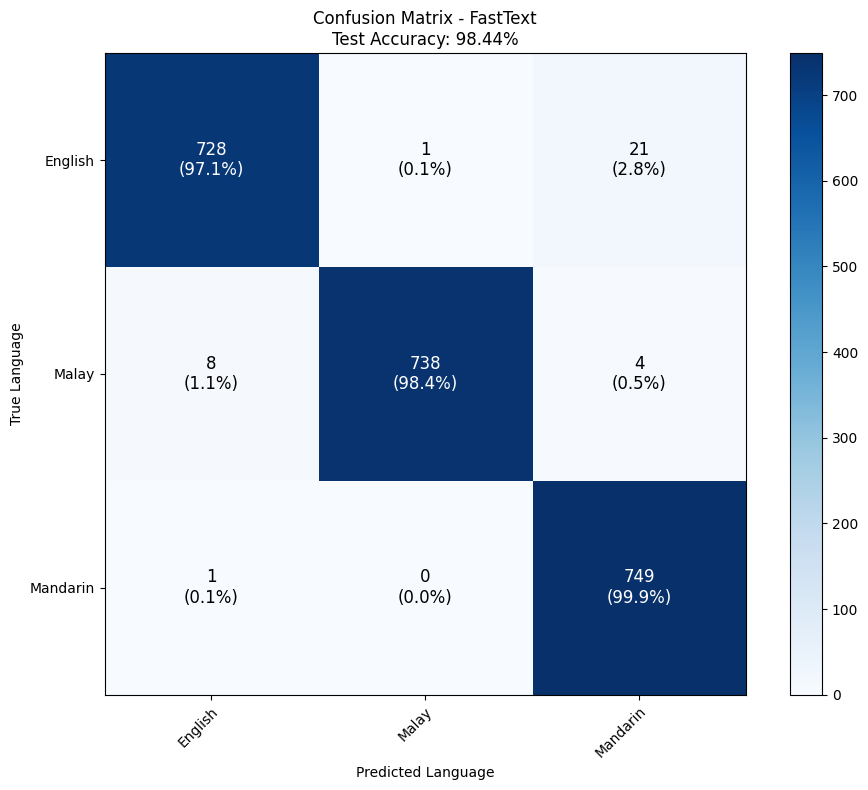

[Display] Confusion matrix shown above.


In [12]:
# Generate and display confusion matrix.
# Shows true vs. predicted labels; diagonal entries are correct predictions.
cm = confusion_matrix(test_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=LANG_NAMES, yticklabels=LANG_NAMES,
       title=f'Confusion Matrix - FastText\nTest Accuracy: {test_acc:.2f}%',
       ylabel='True Language',
       xlabel='Predicted Language')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations showing counts and percentages for each cell.
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        percentage = 100. * cm[i, j] / cm[i].sum() if cm[i].sum() > 0 else 0
        text = f'{cm[i, j]}\n({percentage:.1f}%)'
        ax.text(j, i, text,
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12)

plt.tight_layout()
plt.show()  # Display in notebook instead of saving

print(f"[Display] Confusion matrix shown above.")

In [13]:
# Export detailed test predictions and metrics.
results_df = pd.DataFrame({
    'true_label': [LANG_NAMES[l] for l in test_labels],
    'predicted_label': [LANG_NAMES[p] for p in all_preds],
    'true_id': test_labels,
    'predicted_id': all_preds,
    'confidence': all_probs
})

results_df.to_csv('fasttext_test_predictions.csv', index=False)
print("[Save] Test predictions exported: fasttext_test_predictions.csv")

# Compute precision, recall, F1 score for each language.
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, all_preds, average=None, labels=[0, 1, 2]
)

# Compile comprehensive metrics summary including config and results.
metrics_summary = {
    'model': 'FastText (Noisy OCR Images)',
    'test_accuracy': float(test_acc),
    'train_accuracy': float(train_acc),
    'val_accuracy': float(val_acc),
    'per_language': {
        LANG_NAMES[i]: {
            'precision': float(precision[i]),
            'recall': float(recall[i]),
            'f1_score': float(f1[i]),
            'support': int(support[i])
        }
        for i in range(len(LANG_NAMES))
    },
    'confusion_matrix': cm.tolist(),
    'config': {
        'epoch': EPOCH,
        'lr': LR,
        'dim': DIM,
        'minn': MINN,
        'maxn': MAXN,
        'wordNgrams': WORD_NGRAMS,
        'loss': 'softmax'
    }
}

with open('fasttext_metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("[Save] Metrics summary exported: fasttext_metrics_summary.json")
print("\n" + "="*60)
print("[Done] FASTTEXT EVALUATION COMPLETE")
print("="*60)

[Save] Test predictions exported: fasttext_test_predictions.csv
[Save] Metrics summary exported: fasttext_metrics_summary.json

[Done] FASTTEXT EVALUATION COMPLETE


In [1]:
import json
import pandas as pd

# Load saved FastText metrics summary
with open('fasttext_metrics_summary.json', 'r', encoding='utf-8') as f:
    metrics = json.load(f)

print("=" * 60)
print("FASTTEXT CLASSIFICATION REPORT")
print("=" * 60)

print(f"Model          : {metrics['model']}")
print(f"Test Accuracy  : {metrics['test_accuracy']:.2f}%")
print(f"Train Accuracy : {metrics['train_accuracy']:.2f}%")
print(f"Val Accuracy   : {metrics['val_accuracy']:.2f}%")
print()

# Convert per-language metrics to table
report_rows = []

for lang, scores in metrics['per_language'].items():
    report_rows.append({
        'Language': lang,
        'Precision': scores['precision'],
        'Recall': scores['recall'],
        'F1-Score': scores['f1_score'],
        'Support': scores['support']
    })

report_df = pd.DataFrame(report_rows)

# Display as percentages
display_df = report_df.copy()
display_df['Precision'] = display_df['Precision'].apply(lambda x: f"{x * 100:.2f}%")
display_df['Recall'] = display_df['Recall'].apply(lambda x: f"{x * 100:.2f}%")
display_df['F1-Score'] = display_df['F1-Score'].apply(lambda x: f"{x * 100:.2f}%")

display(display_df)

# Optional: macro and weighted averages
macro_precision = report_df['Precision'].mean()
macro_recall = report_df['Recall'].mean()
macro_f1 = report_df['F1-Score'].mean()

weighted_precision = (report_df['Precision'] * report_df['Support']).sum() / report_df['Support'].sum()
weighted_recall = (report_df['Recall'] * report_df['Support']).sum() / report_df['Support'].sum()
weighted_f1 = (report_df['F1-Score'] * report_df['Support']).sum() / report_df['Support'].sum()

print("\nMacro Average:")
print(f"  Precision: {macro_precision * 100:.2f}%")
print(f"  Recall   : {macro_recall * 100:.2f}%")
print(f"  F1-Score : {macro_f1 * 100:.2f}%")

print("\nWeighted Average:")
print(f"  Precision: {weighted_precision * 100:.2f}%")
print(f"  Recall   : {weighted_recall * 100:.2f}%")
print(f"  F1-Score : {weighted_f1 * 100:.2f}%")

FASTTEXT CLASSIFICATION REPORT
Model          : FastText (Noisy OCR Images)
Test Accuracy  : 98.44%
Train Accuracy : 100.00%
Val Accuracy   : 98.49%



,Language,Precision,Recall,F1-Score,Support
0,English,98.78%,97.07%,97.92%,750
1,Malay,99.86%,98.40%,99.13%,750
2,Mandarin,96.77%,99.87%,98.29%,750



Macro Average:
  Precision: 98.47%
  Recall   : 98.44%
  F1-Score : 98.45%

Weighted Average:
  Precision: 98.47%
  Recall   : 98.44%
  F1-Score : 98.45%


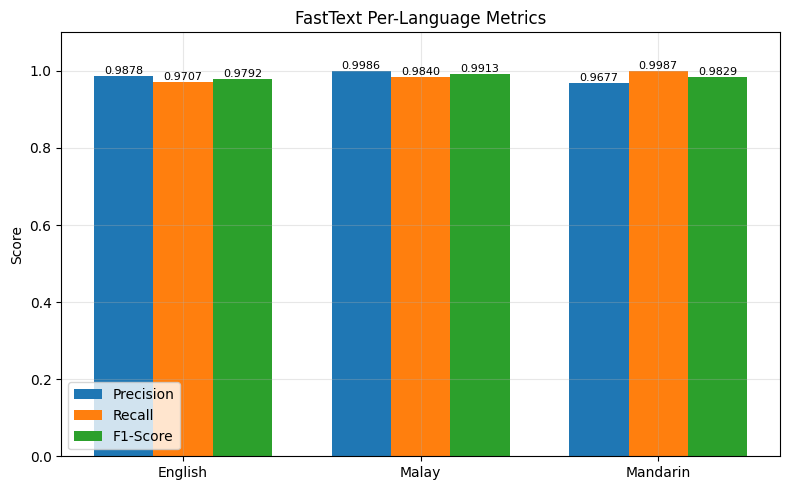

In [6]:
# Visualization: CNN 7.5h Per-language metrics
import numpy as np
import matplotlib.pyplot as plt

LANG_NAMES = ['English', 'Malay', 'Mandarin']

# Newest 

precision = np.array([0.9878, 0.9986, 0.9677])
recall    = np.array([0.9707, 0.9840, 0.9987])
f1        = np.array([0.9792, 0.9913, 0.9829])

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(LANG_NAMES))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision')
bars2 = ax.bar(x, recall, width, label='Recall')
bars3 = ax.bar(x + width, f1, width, label='F1-Score')

ax.set_xticks(x)
ax.set_xticklabels(LANG_NAMES)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('FastText Per-Language Metrics')
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.show()

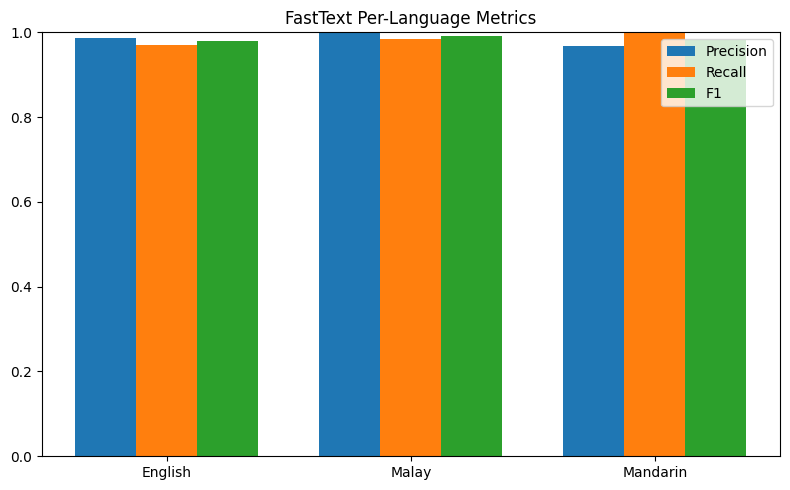

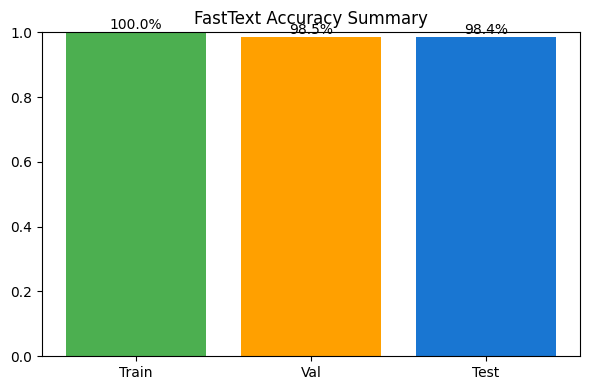

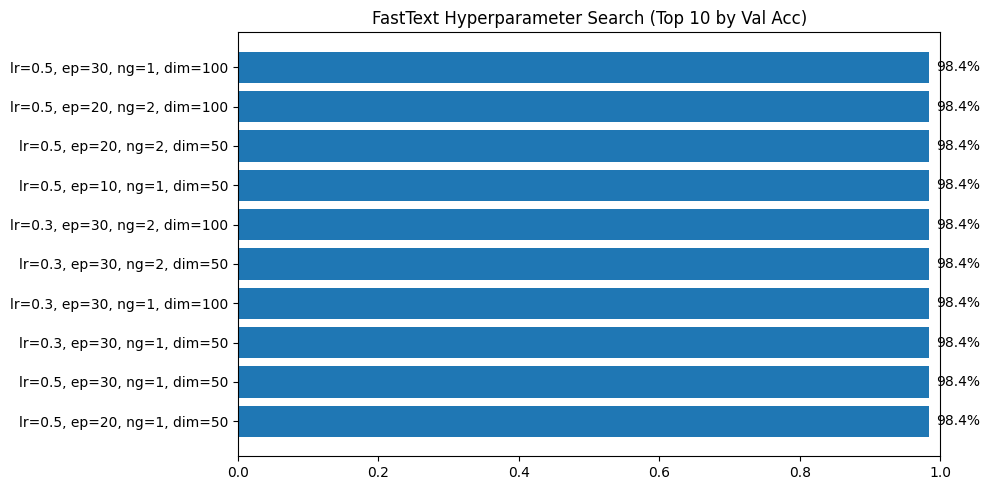

In [14]:
# Visualization: FastText metrics
import matplotlib.pyplot as plt

# Per-language precision/recall/F1
if 'metrics_summary' in globals():
    per_lang = metrics_summary['per_language']
    langs = list(per_lang.keys())
    precision_vals = [per_lang[l]['precision'] for l in langs]
    recall_vals = [per_lang[l]['recall'] for l in langs]
    f1_vals = [per_lang[l]['f1_score'] for l in langs]

    x = np.arange(len(langs))
    width = 0.25
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width, precision_vals, width, label='Precision')
    ax.bar(x, recall_vals, width, label='Recall')
    ax.bar(x + width, f1_vals, width, label='F1')
    ax.set_xticks(x)
    ax.set_xticklabels(langs)
    ax.set_ylim(0, 1)
    ax.set_title('FastText Per-Language Metrics')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('metrics_summary not found; run evaluation first.')

# Accuracy summary (train/val/test)
if 'train_acc' in globals() and 'val_acc' in globals() and 'test_acc' in globals():
    acc_labels = ['Train', 'Val', 'Test']
    acc_values = [train_acc / 100.0, val_acc / 100.0, test_acc / 100.0]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(acc_labels, acc_values, color=['#4caf50', '#ffa000', '#1976d2'])
    ax.set_ylim(0, 1)
    ax.set_title('FastText Accuracy Summary')
    for i, v in enumerate(acc_values):
        ax.text(i, v + 0.01, f'{v*100:.1f}%', ha='center')
    plt.tight_layout()
    plt.show()

# Hyperparameter search results (top 10 by val accuracy)
if 'results_sorted' in globals():
    top_k = results_sorted[:10]
    labels_top = [f"lr={r['lr']}, ep={r['epoch']}, ng={r['wordNgrams']}, dim={r['dim']}" for r in top_k]
    acc_top = [r['val_acc'] / 100.0 for r in top_k]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(labels_top, acc_top)
    ax.set_xlim(0, 1)
    ax.set_title('FastText Hyperparameter Search (Top 10 by Val Acc)')
    for i, v in enumerate(acc_top):
        ax.text(v + 0.01, i, f'{v*100:.1f}%', va='center')
    plt.tight_layout()
    plt.show()
else:
    print('results_sorted not found; run tuning cell first.')

[Setup] Using images from: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images_noisy
[Setup] Languages to test: ['EN', 'MY', 'CN']

[Loading] FastText model...
[OK] Using local FastText model: fasttext_best_model.bin
[Loading] EasyOCR readers (language-specific)...

[Processing] Analyzing images across all languages...

[EN] Processing 5000 images...
  [OK] EN accuracy: 89.38%

[MY] Processing 5000 images...
  [OK] MY accuracy: 93.24%

[CN] Processing 5000 images...
  [OK] CN accuracy: 100.00%


[Results] Overall OCR + FastText Accuracy Across All Languages
Overall Accuracy: 94.21%

[Breakdown] Per-Language Accuracy:
  English: 89.38% (5000 samples)
  Malay: 93.24% (5000 samples)
  Chinese: 100.00% (5000 samples)

[Report] Classification Report
              precision    recall  f1-score   support

     English     0.9764    0.8938    0.9333      5000
       Malay     0.9875    0.9324    0.9592      5000
     Chinese     0.8769    1.0000    0.9344      5000

    accuracy    

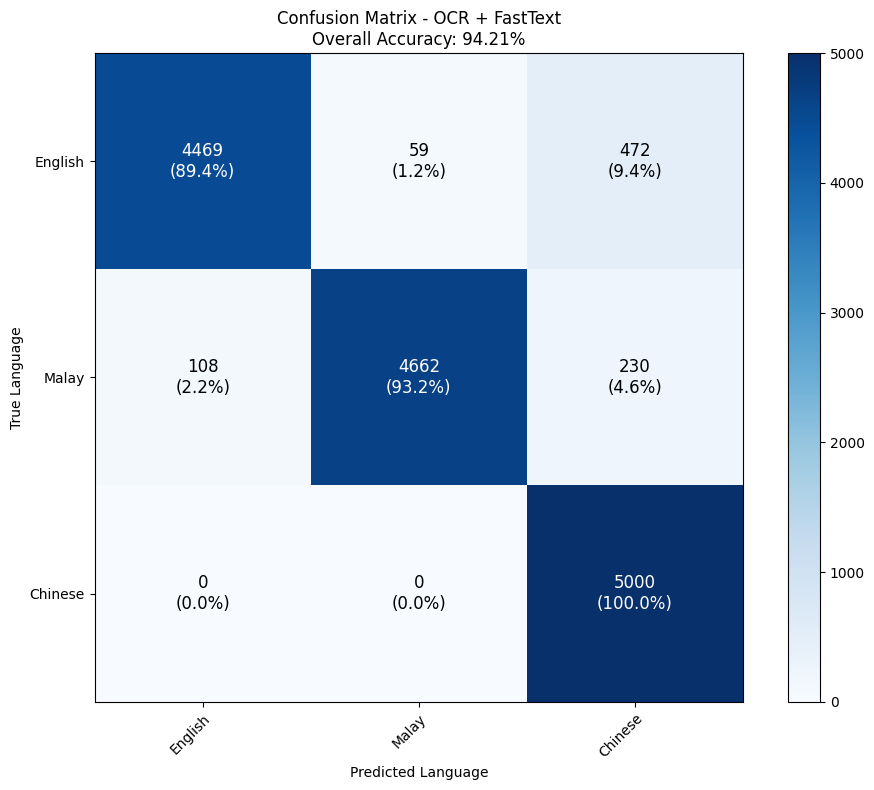


[Done] OCR + FastText evaluation complete!


In [20]:
# Advanced Analysis: Combined OCR + FastText Evaluation on All Languages
# This cell processes images from all three language directories (EN, MY, CN),
# extracts text using EasyOCR, classifies with FastText, and displays accuracy metrics.

import os
import random
import csv
import fasttext
import easyocr
import requests
import re
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Base directory and language configuration
ocr_base_dir = os.path.join(os.getcwd(), 'ocr_images_noisy')
if not os.path.exists(ocr_base_dir):
    ocr_base_dir = os.path.join(os.getcwd(), 'ocr_images')

fasttext_model_path = "fasttext_best_model.bin"
LANGS = ['EN', 'MY', 'CN']
LANG_NAMES = ['English', 'Malay', 'Chinese']
LANG_MAP = {'EN': 0, 'MY': 1, 'CN': 2}

print(f"[Setup] Using images from: {ocr_base_dir}")
print(f"[Setup] Languages to test: {LANGS}\n")

# Helper function: Clean text by normalizing whitespace and special characters.
def clean_text(s: str) -> str:
    """Remove newlines, tabs and collapse multiple spaces into one."""
    if not isinstance(s, str):
        s = str(s)
    s = re.sub(r"[\r\n\t]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

# Load FastText model with fallback mechanism.
def ensure_fasttext_model(path: str):
    """Load local FastText model; if missing, download LID-176 as fallback."""
    if os.path.exists(path):
        print(f"[OK] Using local FastText model: {path}")
        return fasttext.load_model(path)
    fallback_url = "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin"
    fallback_path = "lid.176.bin"
    print(f"[Warning] {path} not found. Downloading fallback LID model...")
    try:
        with requests.get(fallback_url, stream=True, timeout=60) as r:
            r.raise_for_status()
            with open(fallback_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
        print("[OK] Download complete. Loading LID model...")
        return fasttext.load_model(fallback_path)
    except Exception as e:
        raise RuntimeError(f"Failed to download/load FastText model: {e}")

# Load FastText model
print("[Loading] FastText model...")
ft_model = ensure_fasttext_model(fasttext_model_path)

# Initialize EasyOCR readers with language-specific compatibility.
# Note: EasyOCR has compatibility constraints - Chinese Simplified only works with English.
print("[Loading] EasyOCR readers (language-specific)...")
gpu_available = True if __import__('torch').cuda.is_available() else False
reader_en = easyocr.Reader(['en'], gpu=gpu_available)  # English only
reader_cn = easyocr.Reader(['ch_sim', 'en'], gpu=gpu_available)  # Chinese Simplified + English
reader_ms = easyocr.Reader(['ms', 'en'], gpu=gpu_available)  # Malay + English

# Map languages to their appropriate readers
reader_map = {
    'EN': reader_en,
    'MY': reader_ms,
    'CN': reader_cn
}

# Process all languages and collect results
all_true_labels = []
all_pred_labels = []
all_pred_probs = []
results_per_lang = {}

print("\n[Processing] Analyzing images across all languages...\n")

for lang in LANGS:
    lang_dir = os.path.join(ocr_base_dir, lang)
    labels_file = os.path.join(lang_dir, 'labels_noisy.csv')
    if not os.path.exists(labels_file):
        labels_file = os.path.join(lang_dir, 'labels.csv')
    
    if not os.path.exists(labels_file):
        print(f"[Warning] {lang}: labels file not found, skipping...")
        continue
    
    # Load image list and true labels
    true_labels_lang = []
    image_files = []
    with open(labels_file, 'r', encoding='utf-8') as f:
        reader_csv = csv.DictReader(f)
        for row in reader_csv:
            if 'filename' in row:
                image_files.append(row['filename'])
                true_labels_lang.append(LANG_MAP[lang])
    
    print(f"[{lang}] Processing {len(image_files)} images...")
    
    pred_labels_lang = []
    pred_probs_lang = []
    
    # Get the appropriate reader for this language
    ocr_reader = reader_map[lang]
    
    # Process all images from this language
    for image_file in image_files:
        image_path = os.path.join(lang_dir, image_file)
        
        if not os.path.exists(image_path):
            pred_labels_lang.append(0)  # default to English if image not found
            pred_probs_lang.append(0.0)
            continue
        
        try:
            # Extract text using language-specific EasyOCR reader
            ocr_result = ocr_reader.readtext(image_path, detail=0)
            text = clean_text(" ".join(ocr_result))
            
            if not text:
                pred_labels_lang.append(0)
                pred_probs_lang.append(0.0)
                continue
            
            # Classify language using FastText
            label, confidence = ft_model.predict(text)
            lang_code = label[0].replace("__label__", "")
            pred_id = LANG_NAMES.index(lang_code.capitalize()) if lang_code.capitalize() in LANG_NAMES else 0
            pred_labels_lang.append(pred_id)
            pred_probs_lang.append(float(confidence[0]))
        
        except Exception as e:
            pred_labels_lang.append(0)
            pred_probs_lang.append(0.0)
    
    # Store results for this language
    results_per_lang[lang] = {
        'true': true_labels_lang,
        'pred': pred_labels_lang,
        'probs': pred_probs_lang
    }
    
    # Accumulate for overall metrics
    all_true_labels.extend(true_labels_lang)
    all_pred_labels.extend(pred_labels_lang)
    all_pred_probs.extend(pred_probs_lang)
    
    lang_acc = 100.0 * np.sum(np.array(pred_labels_lang) == np.array(true_labels_lang)) / len(true_labels_lang)
    print(f"  [OK] {lang} accuracy: {lang_acc:.2f}%\n")

# Convert to numpy arrays for metrics computation
all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)

# Compute overall metrics
overall_acc = 100.0 * accuracy_score(all_true_labels, all_pred_labels)

print("\n" + "="*60)
print("[Results] Overall OCR + FastText Accuracy Across All Languages")
print("="*60)
print(f"Overall Accuracy: {overall_acc:.2f}%\n")

# Per-language accuracy breakdown
print("[Breakdown] Per-Language Accuracy:")
for lang_id, lang_name in enumerate(LANG_NAMES):
    mask = all_true_labels == lang_id
    if np.sum(mask) > 0:
        lang_acc = 100.0 * np.sum(all_pred_labels[mask] == lang_id) / np.sum(mask)
        count = np.sum(mask)
        print(f"  {lang_name}: {lang_acc:.2f}% ({count} samples)")

# Classification report
print("\n" + "="*60)
print("[Report] Classification Report")
print("="*60)
print(classification_report(all_true_labels, all_pred_labels, target_names=LANG_NAMES, digits=4))

# Confusion matrix
cm = confusion_matrix(all_true_labels, all_pred_labels)
print("\n" + "="*60)
print("[Matrix] Confusion Matrix")
print("="*60)
print("Rows: True Label | Columns: Predicted Label\n")
print("     ", "  ".join(f"{name:8}" for name in LANG_NAMES))
for i, lang_name in enumerate(LANG_NAMES):
    print(f"{lang_name:8}", "  ".join(f"{cm[i,j]:8}" for j in range(len(LANG_NAMES))))

# Display confusion matrix visualization
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=LANG_NAMES, yticklabels=LANG_NAMES,
       title=f'Confusion Matrix - OCR + FastText\nOverall Accuracy: {overall_acc:.2f}%',
       ylabel='True Language',
       xlabel='Predicted Language')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        percentage = 100. * cm[i, j] / cm[i].sum() if cm[i].sum() > 0 else 0
        text = f'{cm[i, j]}\n({percentage:.1f}%)'
        ax.text(j, i, text,
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12)

plt.tight_layout()
plt.show()

print("\n[Done] OCR + FastText evaluation complete!")